<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
#!wget -O survey-data.sqlite 
import requests

url= 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite'
r = requests.get(url)
with open('survey-results-public.sqlite', 'wb') as f:
    f.write(r.content)

#### Install the required libraries and import them


In [2]:
# !pip install pandas

In [3]:
# !pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-results-public.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name
FROM sqlite_master
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)

                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [9]:
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""

df_hist = pd.read_sql_query(QUERY, conn)
df_hist.describe()

,CompTotal
count,3.374000e+04
mean,2.963841e+145
std,5.444117e+147
min,0.000000e+00
25%,6.000000e+04
50%,1.100000e+05
75%,2.500000e+05
max,1.000000e+150


In [10]:
q1 = df_hist.quantile(.25)
q3 = df_hist.quantile(.75)
iqr = q3 - q1
upper_bounds = iqr * 1.5 + q3
df_hist = df_hist[df_hist < upper_bounds]
df_hist.describe()

,CompTotal
count,27861.000000
mean,117137.615879
std,99881.615371
min,0.000000
25%,50000.000000
50%,88000.000000
75%,150000.000000
max,534000.000000


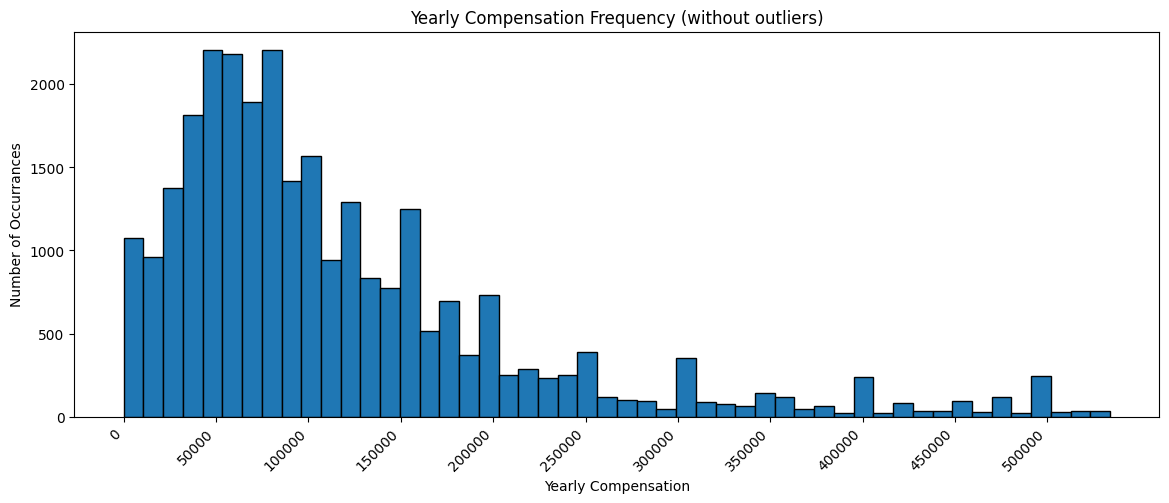

In [11]:
plt.figure(figsize = (14,5))
plt.hist(df_hist, bins = 50, edgecolor='black')
plt.xlabel('Yearly Compensation')
plt.ylabel('Number of Occurrances')
plt.title('Yearly Compensation Frequency (without outliers)')
plt.xticks(ticks = range(0, 550000, 50000), rotation = 45, ha='right')
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [12]:
QUERY = """
SELECT YearsCodePro
FROM main
WHERE YearsCodePro IS NOT NULL;
"""

df_ycp = pd.read_sql_query(QUERY, conn)
df_ycp.describe()

,YearsCodePro
count,51610
unique,52
top,2
freq,4168


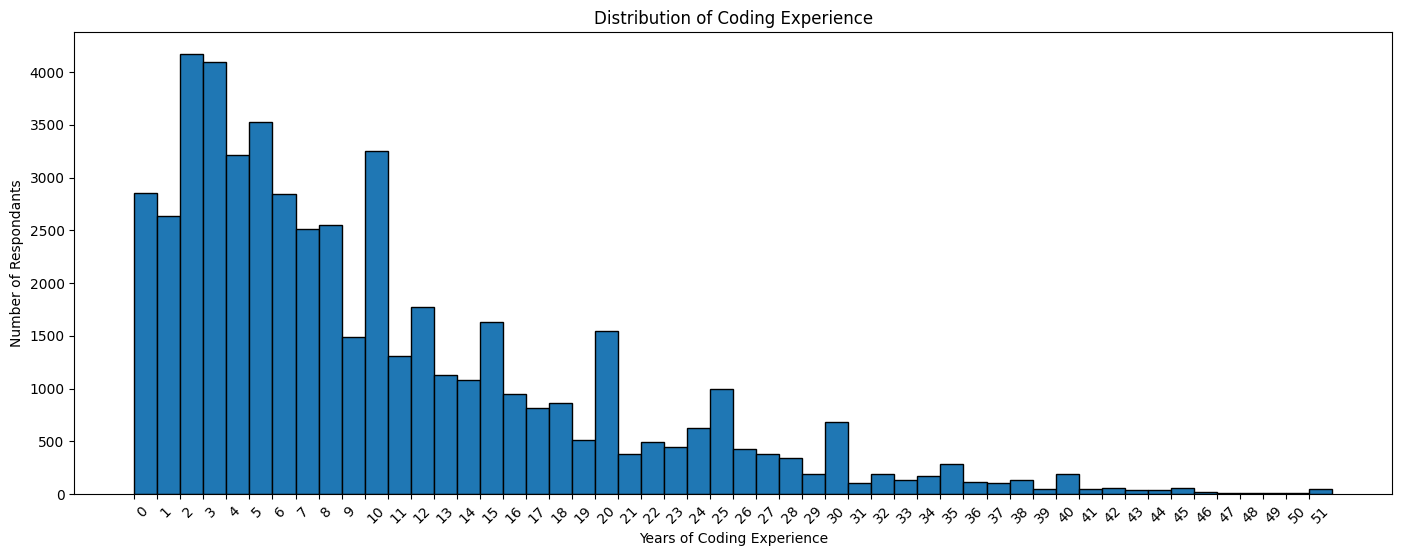

In [13]:
df_ycp = df_ycp.replace({'Less than 1 year': '0', 'More than 50 years': '51'}) # need to make numbers for int conversion
df_ycp['YearsCodePro'] = df_ycp['YearsCodePro'].astype(int) # converting to type integer for numerical sequencing on histogram
df_ycp = df_ycp.sort_values('YearsCodePro') # sorting for histogram readability

plt.figure(figsize = (17, 6))
plt.hist(df_ycp, bins= range(0, 53, 1), edgecolor='black', )
plt.title('Distribution of Coding Experience')
plt.ylabel('Number of Respondants')
plt.xlabel('Years of Coding Experience')
plt.xticks(ticks = range(0, 52, 1), rotation=45, ha='left')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [14]:
upper_bounds # looking to find cutoff value from before to exclude outliers

CompTotal    535000.0
dtype: float64

In [15]:
QUERY = """
SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL
AND Age IS NOT NULL
AND Age != 'Prefer not to say'
AND CompTotal < 535000;
"""
df_comp_age = pd.read_sql_query(QUERY, conn)
df_comp_age.head()

,CompTotal,Age
0,28000.0,25-34 years old
1,85000.0,35-44 years old
2,50000.0,35-44 years old
3,110000.0,25-34 years old
4,126420.0,35-44 years old


In [16]:
age_groups = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
age_groups

['Under 18 years old',
 '18-24 years old',
 '25-34 years old',
 '35-44 years old',
 '45-54 years old',
 '55-64 years old',
 '65 years or older']

In [17]:
df_comp_age.value_counts()

CompTotal  Age            
60000.0    25-34 years old    374
100000.0   25-34 years old    365
50000.0    25-34 years old    321
120000.0   25-34 years old    303
100000.0   35-44 years old    302
                             ... 
2520.0     18-24 years old      1
254600.0   35-44 years old      1
247433.0   35-44 years old      1
157000.0   45-54 years old      1
77700.0    25-34 years old      1
Name: count, Length: 3779, dtype: int64

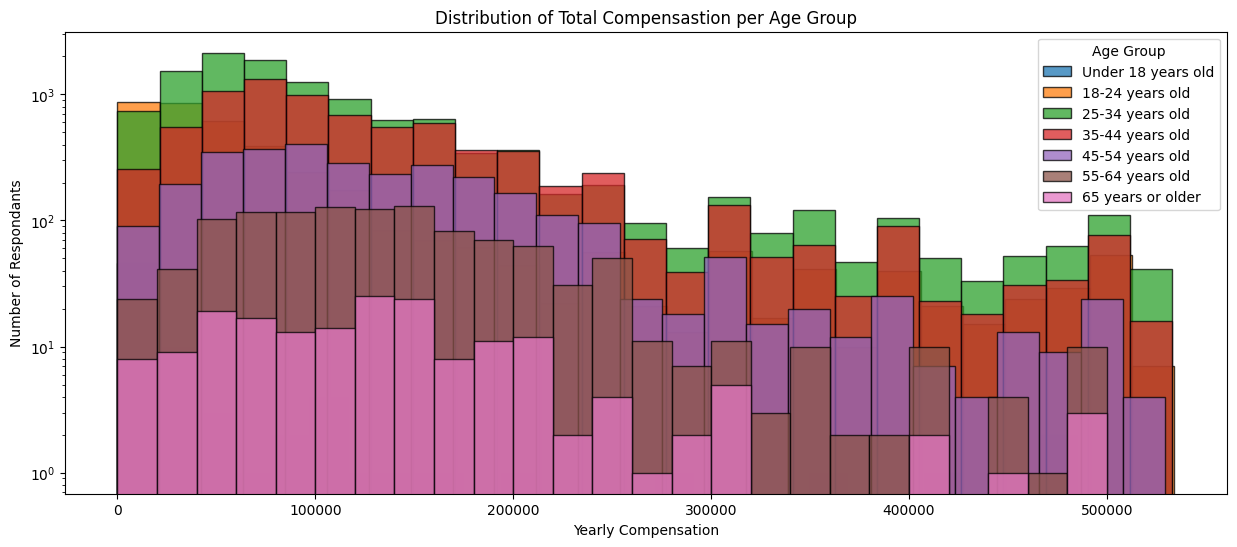

In [18]:
plt.figure(figsize = (15, 6))
for age in age_groups:
    plt.hist(df_comp_age.loc[df_comp_age['Age'] == age, 'CompTotal'],
             bins = 25,
             alpha = 0.75,
             edgecolor = 'black',
             label = age)

plt.title('Distribution of Total Compensastion per Age Group')
plt.ylabel('Number of Respondants')
plt.yscale('log')
plt.xlabel('Yearly Compensation')
plt.legend(title='Age Group')
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [19]:
QUERY = """SELECT TimeSearching, Age
FROM main
WHERE Age IS NOT NULL
AND TimeSearching IS NOT NULL
AND Age != 'Prefer not to say';
"""
df_search_age = pd.read_sql_query(QUERY, conn)
df_search_age.head()

,TimeSearching,Age
0,30-60 minutes a day,35-44 years old
1,30-60 minutes a day,35-44 years old
2,60-120 minutes a day,45-54 years old
3,15-30 minutes a day,25-34 years old
4,Less than 15 minutes a day,25-34 years old


In [20]:
df_search_age = df_search_age.replace({'Less than 15 minutes a day': '0 to 15 minutes a day'})

In [21]:
df_search_age1 = df_search_age.sort_values('TimeSearching', ascending = True)
df_search_age1

,TimeSearching,Age
4,0 to 15 minutes a day,25-34 years old
24,0 to 15 minutes a day,45-54 years old
29,0 to 15 minutes a day,55-64 years old
55,0 to 15 minutes a day,25-34 years old
58,0 to 15 minutes a day,35-44 years old
...,...,...
28810,Over 120 minutes a day,18-24 years old
28818,Over 120 minutes a day,55-64 years old
28827,Over 120 minutes a day,45-54 years old
28834,Over 120 minutes a day,25-34 years old


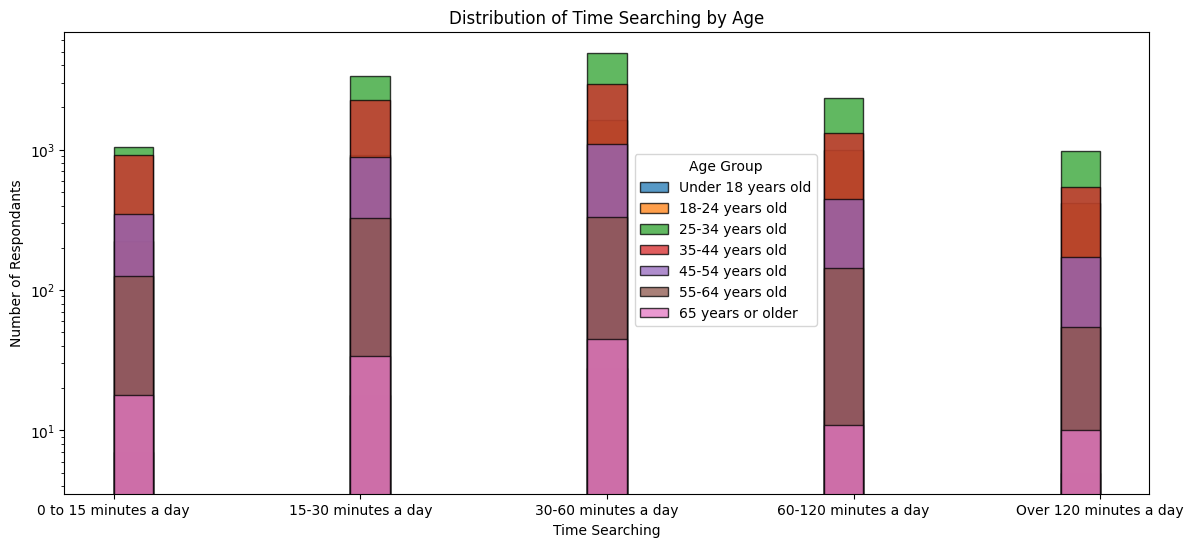

In [22]:
plt.figure(figsize = (14, 6))
for age in age_groups:
    plt.hist(df_search_age1.loc[df_search_age1['Age'] == age, 'TimeSearching'],
             bins = 25,
             alpha = .75,
             edgecolor = 'black',
             label = age)
plt.xlabel('Time Searching')
plt.ylabel('Number of Respondants')
plt.yscale('log')

plt.title('Distribution of Time Searching by Age')
plt.legend(title = 'Age Group', bbox_to_anchor = (0.7, 0.75))
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [23]:
QUERY = """SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL;
"""
df_db_want = pd.read_sql_query(QUERY, conn)
df_db_want.head()

,DatabaseWantToWorkWith
0,PostgreSQL
1,Firebase Realtime Database
2,MongoDB;MySQL;PostgreSQL
3,PostgreSQL;SQLite
4,Cloud Firestore


In [24]:
df_db_want = df_db_want['DatabaseWantToWorkWith'].str.split(';').explode() # exploding to full list of all desired databases
df_db_want

0                        PostgreSQL
1        Firebase Realtime Database
2                           MongoDB
2                             MySQL
2                        PostgreSQL
                    ...            
42556                    PostgreSQL
42556                        SQLite
42557                       MongoDB
42557                         MySQL
42557                    PostgreSQL
Name: DatabaseWantToWorkWith, Length: 127439, dtype: str

In [25]:
df_db_want = pd.DataFrame(df_db_want, columns=['DatabaseWantToWorkWith'])
df_db_want

,DatabaseWantToWorkWith
0,PostgreSQL
1,Firebase Realtime Database
2,MongoDB
2,MySQL
2,PostgreSQL
...,...
42556,PostgreSQL
42556,SQLite
42557,MongoDB
42557,MySQL


In [26]:
top5 = list(df_db_want.value_counts(subset='DatabaseWantToWorkWith').head(5).index) # make list of top 5 to keep/not-drop
top5

['PostgreSQL', 'SQLite', 'MySQL', 'MongoDB', 'Redis']

In [27]:
df_db_want = df_db_want.reset_index(drop=True) # resetting index due to duplicates from explode

In [28]:
rows = df_db_want.loc[df_db_want['DatabaseWantToWorkWith'].isin(top5) == False] # list of rows containing index values to drop
df_top5 = df_db_want.drop(rows.index) # dropping rows not in top5 list
df_top5

,DatabaseWantToWorkWith
0,PostgreSQL
2,MongoDB
3,MySQL
4,PostgreSQL
5,PostgreSQL
...,...
127434,PostgreSQL
127435,SQLite
127436,MongoDB
127437,MySQL


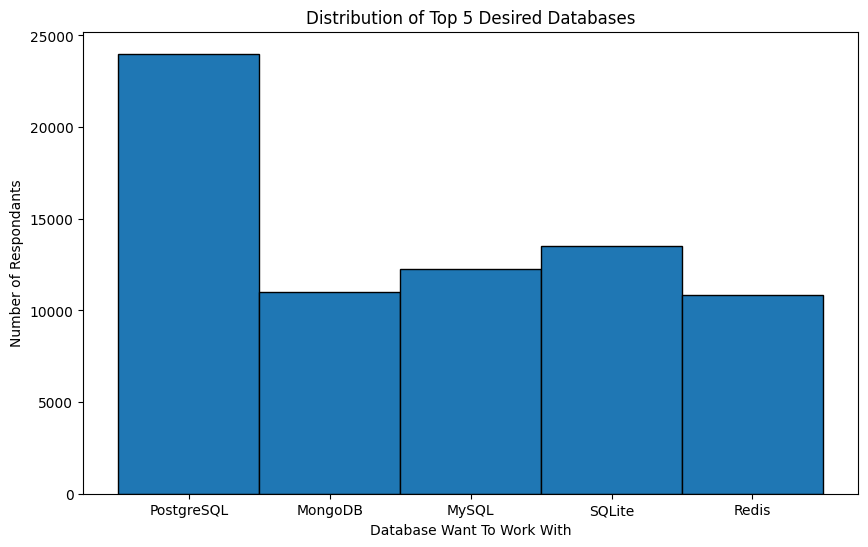

In [29]:
plt.figure(figsize = (10,6))
n, bins, patches = plt.hist(df_top5,
                            bins = 5,
                            label = df_top5.index,
                            edgecolor = 'black')
plt.xlabel('Database Want To Work With')
plt.ylabel('Number of Respondants')
plt.title('Distribution of Top 5 Desired Databases')
bin_centers = (bins[:-1] + bins[1:]) / 2 # find the center of the bins
plt.xticks(bin_centers)
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [30]:
QUERY = """SELECT RemoteWork
FROM main
WHERE RemoteWork IS NOT NULL;
"""
df_remote = pd.read_sql_query(QUERY, conn)
df_remote.value_counts()

RemoteWork                          
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

In [31]:
df_remote = df_remote.replace('Hybrid (some remote, some in-person)', 'Hybrid')

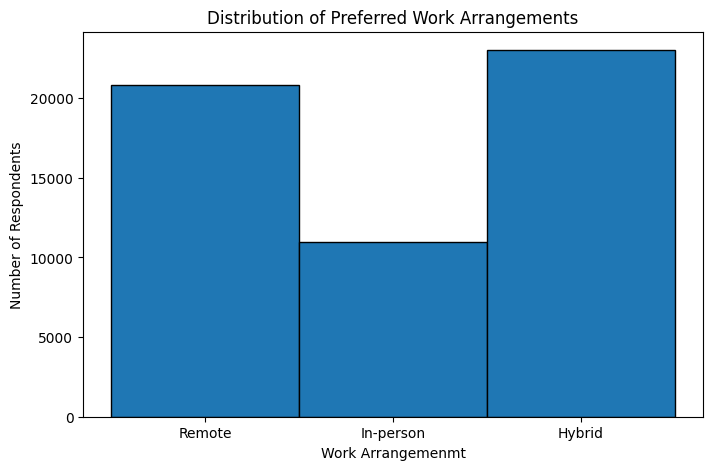

In [32]:
plt.figure(figsize = (8, 5))
n, bins, patches = plt.hist(df_remote, bins = 3, edgecolor = 'black')
plt.xlabel('Work Arrangemenmt')
plt.ylabel('Number of Respondents')
plt.title('Distribution of Preferred Work Arrangements')
bin_centers = (bins[:-1] + bins[1:]) / 2 # find the center of the bins
plt.xticks(bin_centers)
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [33]:
QUERY = """SELECT CompTotal, Age
FROM main
WHERE (Age == '45-54 years old' OR Age == '55-64 years old')
AND CompTotal IS NOT NULL;
"""
df_comp_age = pd.read_sql_query(QUERY, conn)
df_comp_age

,CompTotal,Age
0,95000.0,45-54 years old
1,195000.0,45-54 years old
2,54000.0,55-64 years old
3,145000.0,45-54 years old
4,80000.0,55-64 years old
...,...,...
4790,40000.0,45-54 years old
4791,250000.0,45-54 years old
4792,250000.0,45-54 years old
4793,157000.0,45-54 years old


In [34]:
q1 = df_comp_age['CompTotal'].quantile(.25)
q3 = df_comp_age['CompTotal'].quantile(.75)
iqr = q3 - q1
upper_bounds = iqr * 1.5 + q3

df_comp_age = df_comp_age[df_comp_age['CompTotal'] <= upper_bounds] # removing outliers
df_comp_age.describe() # verifying data is no longer heavily skewed

,CompTotal
count,4093.000000
mean,128060.656242
std,75606.962496
min,0.000000
25%,70000.000000
50%,118651.000000
75%,170000.000000
max,408000.000000


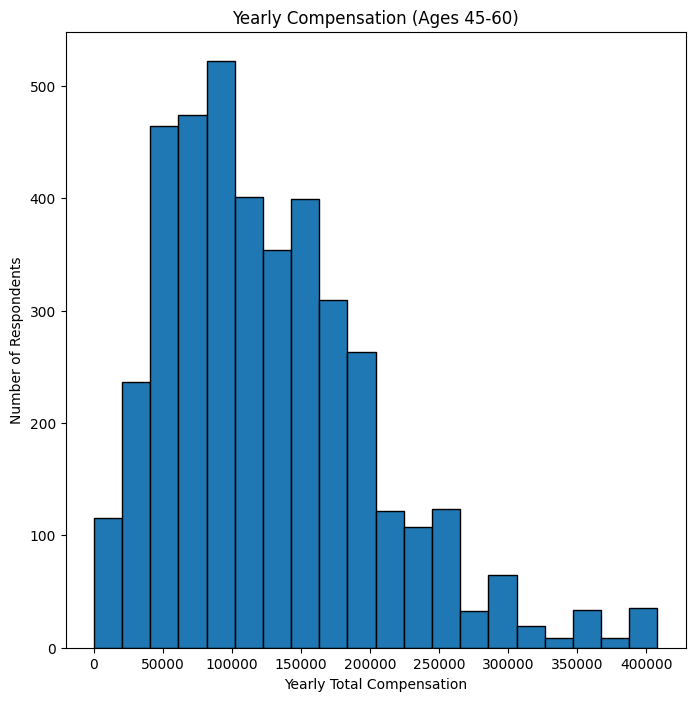

In [35]:
plt.figure(figsize = (8, 8))
plt.hist(df_comp_age['CompTotal'],
         bins = 20,
         edgecolor = 'black')
plt.xlabel('Yearly Total Compensation')
plt.ylabel('Number of Respondents')
plt.title('Yearly Compensation (Ages 45-60)')
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [36]:
QUERY = """SELECT JobSat, YearsCodePro
FROM main
WHERE JobSat IS NOT NULL
AND YearsCodePro IS NOT NULL;
"""
df_jobsat_pro = pd.read_sql_query(QUERY, conn)
df_jobsat_pro

,JobSat,YearsCodePro
0,8.0,12
1,5.0,27
2,10.0,10
3,6.0,Less than 1 year
4,9.0,18
...,...,...
28351,8.0,17
28352,5.0,10
28353,8.0,2
28354,8.0,7


In [37]:
df_jobsat_pro = df_jobsat_pro.replace({'Less than 1 year': 0, 'More than 50 years': 51})
df_jobsat_pro = df_jobsat_pro.astype(int)

In [38]:
bins = [0, 10, 20, 30, 40, 50, 60]
labels = ['0-10 years', '10-20 years', '20-30 years', '30-40 years', '40-50 years', '50+ years']
df_jobsat_pro['Bins'] = pd.cut(df_jobsat_pro['YearsCodePro'], bins = bins, labels = labels, include_lowest = True)
df_jobsat_pro = df_jobsat_pro.drop('YearsCodePro', axis = 1)
df_jobsat_pro

,JobSat,Bins
0,8,10-20 years
1,5,20-30 years
2,10,0-10 years
3,6,0-10 years
4,9,10-20 years
...,...,...
28351,8,10-20 years
28352,5,0-10 years
28353,8,0-10 years
28354,8,0-10 years


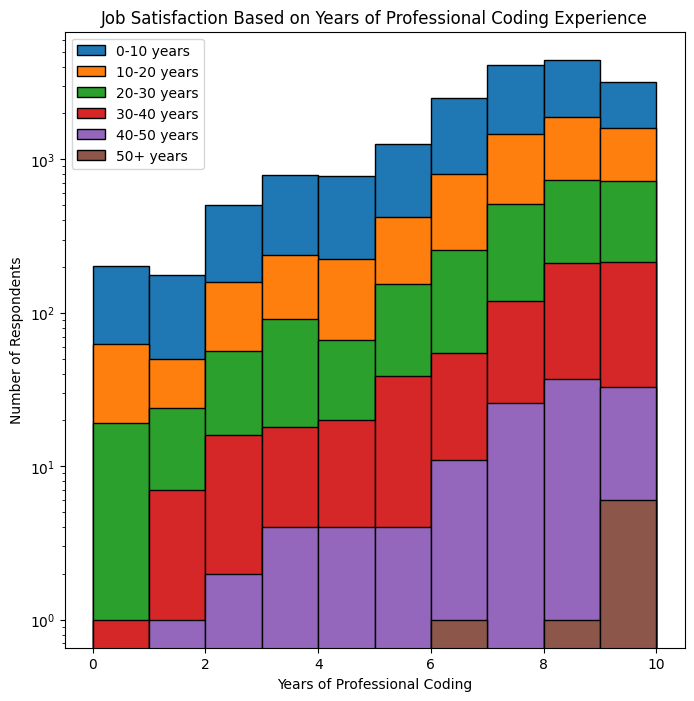

In [39]:
plt.figure(figsize = (8, 8))
for age in labels:
    plt.hist(df_jobsat_pro.loc[df_jobsat_pro['Bins'] == age, 'JobSat'],
             bins = range(0, 11),
             label = labels,
             edgecolor = 'black')
plt.xlabel('Years of Professional Coding')
plt.ylabel('Number of Respondents')
plt.title('Job Satisfaction Based on Years of Professional Coding Experience')
plt.yscale('log')
plt.legend(labels = labels)
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [40]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
